In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider
from datetime import datetime
import math

In [5]:
# function that loads the data, from the csv generated by the 
def readfile(filename):
        # read the CSV file into a dataframe (i.e. like a Python spreadsheet)
    df = pd.read_csv(filename)
    
    # convert dataframe into a 2D Numpy array
    a = df.to_numpy()
    
    # the first column are the counters
    counter_array = a[:,0]
    
    # the second column are the time stamps
    time_array = a[:,1]
    
    # the second column are the time stamps
    # arduino_time_stamp_array = a[:,2]
    
    # the third column are your measurements: either pulseTime or distance depending on how you modified the code above
    temperature_array = a[:,2]
    rh_array = a[:,3]

    return (time_array, temperature_array, rh_array)
    

In [6]:
max_height = 12.3 / 100 # m
min_height = 11 / 100 # m

print(f"Height uncertainty {(max_height - min_height)/ 4 :e}")

max_radius = 3.5 / 100 # m
min_radius = 3.1 / 100 # m

print(f"Radius uncertainty {(max_radius - min_radius)/ 4:e}")

Height uncertainty 3.250000e-03
Radius uncertainty 1.000000e-03


In [7]:

# before you copy-paste your constants, note the changes I have made

# https://illingcompany.com/product/12oz-standard-355ml-202x211-brite-can/?srsltid=AfmBOorGi1H67og6nzUoUixZYzyuDW54VpLvHtOzYKGDkJxL2sChPYh_

# Rough dimensions of can
pi = math.pi
r = 3.31 / 100  # eff radius m
h = 11.2 / 100  # height m 

# estimating exposed surface based on cylinder

A = (2 * (pi * (r **2) )) + (h * (2 * pi * r))   # exposed surface in m^3
V = 355 * (1/(100**3)) # volume in m^3

# https://www.engineeringtoolbox.com/standard-atmosphere-d_604.html
rhoair = 1.225 # approx kg/m^3  ROUGH (depends on T)

# https://kg-m3.com/material/aluminum

rhoAl = 2712 # kg/m3  # density Al

# mass of the air is equal to desnity of air * volume of air
mair = rhoair * V # kg air
mAl = 12.46 / 1000 # NOAH REMEMBER TO WEIGH THE CAN TO GET THIS PREISE # mass of can kg
d = 0.095  # rough thickness of Al  

# https://www.engineeringtoolbox.com/thermal-conductivity-metals-d_858.html
k = 237 # conductivity of Al
# print(mair,d)

# https://www.engineeringtoolbox.com/specific-heat-capacity-d_391.html
# go back to make sure this is correct
cair = 1005 # air J/kg/K
cAl = 897 # Al J/kg/K
heatcap = mAl*cAl + mair*cair

Tcel = 273.15 # to convert C to K

sig = 5.67e-8  # Stefan-Boltzmann W/m^2/K^4

print(f"A: {A}")
print(f"V: {V}")
print(f"mair: {mair}")
print(f"mAl: {mAl}")

A: 0.030176945225175184
V: 0.000355
mair: 0.00043487500000000004
mAl: 0.01246


In [8]:
# this function takes eps, kc, start time and start temp as parameters and runs the euler simulation 
# It is called every time these values are changed by a slider
def euler(kc, eps, initalTime, initalTemp, final_time, Tamb): 
    
    n = 0
    dt = 0.1 # time step (s)
    # If your time step is very low, it will take a long time for the euler simulation to complete, causing the application to stutter. 
    # Try a large-ish time first ~0.1, then go small once you found values you liked. 
    T0   = initalTemp + Tcel   # starting temperature

    tn = initalTime
    Tn = T0

    t = []
    T = []

    while tn < final_time:
        dHc = kc * A * (Tn-Tamb) * dt
        dHr = eps * sig * A * (Tn**4 - Tamb**4) * dt
        Tn = Tn - (dHc + dHr)/heatcap
        tn = tn + dt
        
        delt = (dHc + dHr)*d/k/A/dt  # temp drop across wall of can - check it is tiny
    #    print(delt)
        t.append(tn)     # store the current time
        T.append(Tn-Tcel)     # store the current temperature
        # print(tn,Tn-Tcel)

    return (t, T)

In [9]:
# # this calculated the chi squared goodness of fit score between two series
# # This is my own herbs and spices, be careful, do not cite this metric, only use it to help you determine what you need

# https://en.wikipedia.org/wiki/Chi-squared_test

# The chi-squared test is asymmetric, so I might have implemented it on the wrong variable, I am not a stats guy
# euler data first, (I didn't want to code up the edge case where you have no values to interpolate)
# Observed is first
def chiSquared(x1s, y1s, x2s, y2s): 
    # since they are not aligned on the time axis, we have to do some interpolation. 
    # (the time axis for the experimental temperatures varies, so even if we matched them, they wouldn't fit)

    # I have chosen to do the interpolation on the euler side, since we can generate more euler points than measured points reducing compute time, but you can always flip it

    sum = 0
    for x1, y1 in zip(x1s, y1s): 
        observed_value = y1 # here euler is first, so we are assuming it is the actual and our data is observed, again might be wrong
        # computer slows when flipped, it seems numpy array ops are slow when doing many thousands of array comparisons, 
        # I don't feel like writing something faster, and this works,

        point_after_index = np.searchsorted(x2s, x1)
        point_before_index = point_after_index - 1


        if point_after_index >= len(y2s):
            # we are at the end of the list, so just use the last interpolation  
            point_after_index -= 1
            point_before_index -= 1

        m = (y2s[point_after_index] - y2s[point_before_index])/ (x2s[point_after_index] - x2s[point_before_index])

        interpolated_value = (m * (x1 - x2s[point_before_index])) + y2s[point_before_index]

        sum += ((observed_value - interpolated_value)**2)/ (interpolated_value)

        # UPDATE: Thursday 20th 11:23. 
        # Checked with Gabe about the chi-2, euler data is observed, so this should be flipped


    return sum

# test case, should be 0.0
a = np.array
assert chiSquared(a([0.5, 1.5, 2.5]), a([1, 3, 5]), a([0, 1, 2, 3]), a([0, 2, 4, 6])) == 0.0
chiSquared(a([0.5, 1.5, 2.5]), a([1, 3, 5]), a([0, 1, 2]), a([0, 2, 4]))


0.0

In [10]:
from os import listdir
from os.path import isfile, join
root = "/Users/sam/Desktop/Science One For Real/physics/SCIE001Physics/"
goodPath = root + "dataSorting/bestRuns/"
figures_folder = root + "/figures"
onlyfiles = [f for f in listdir(goodPath) if isfile(join(goodPath, f))]
onlyfiles

['4.csv', '1.csv', '3.csv', '2.csv']

In [11]:
class Dataset: 
    start_temp = 0
    start_time = 0
    kcs = ()
    eps = ()
    name = ""
    trim = 0 
    tamb = 0 

    def __init__(self, start_temp, start_time, kcs, eps, name, trim, tamb): 
        self.start_temp = start_temp
        self.start_time = start_time
        self.kcs = kcs
        self.eps = eps
        self.name = name
        self.trim = trim
        self.tamb = tamb + Tcel # ambient temp (K)

        


In [34]:
datasets = [
    Dataset(32.52602844471632, 319.5494142967266, (0.26556776556776557, 0.41300366300366304, 0.2316849816849817), (0.242197608002777 , 0.20590741266685597, 0.2295749313641957 ), "3", 319.54, 23.2),
    Dataset(39.775776112555434, 436.9175755885931, (0.5943223443223442, 0.30128205128205127, 0.4807692307692308), (0.20590741266685597 , 0.24535327716242228, 0.2074852472466786 ), "4", 436.917, 22.7),
    Dataset(38.02778712341336, 368.56793743655794, (0.32967032967032966, 0.39377289377289376, 0.39285714285714285), (0.24535327716242228, 0.2248414276247278, 0.21853008930543716), "1", 368.567, 23.4)
]

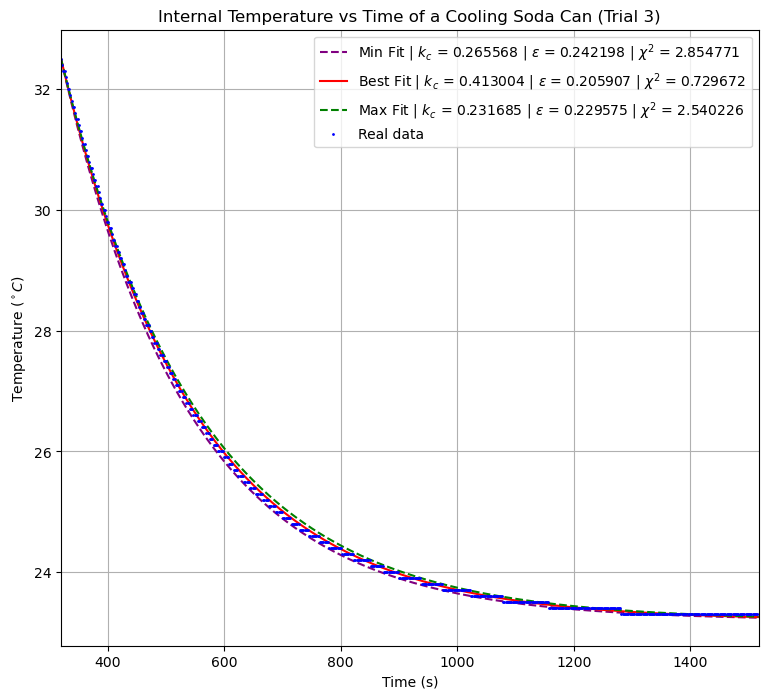

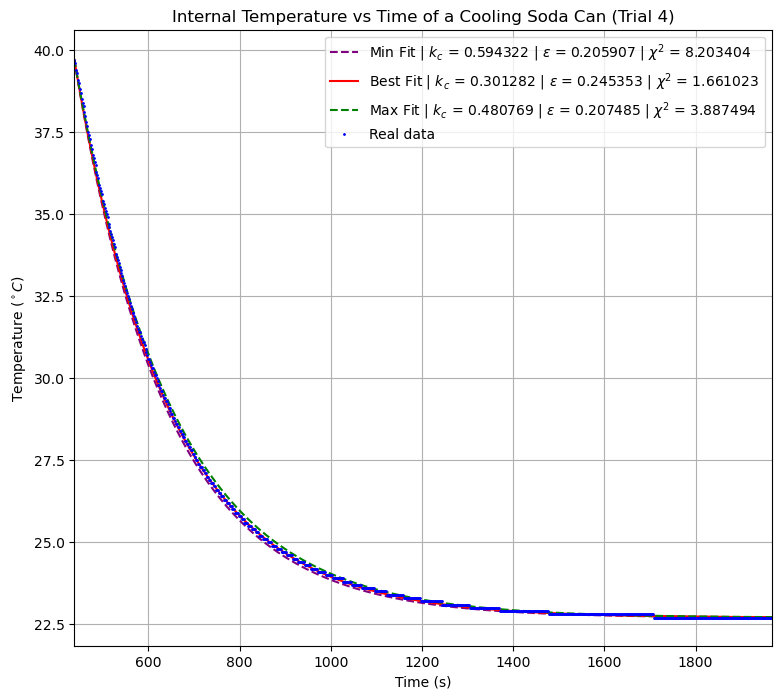

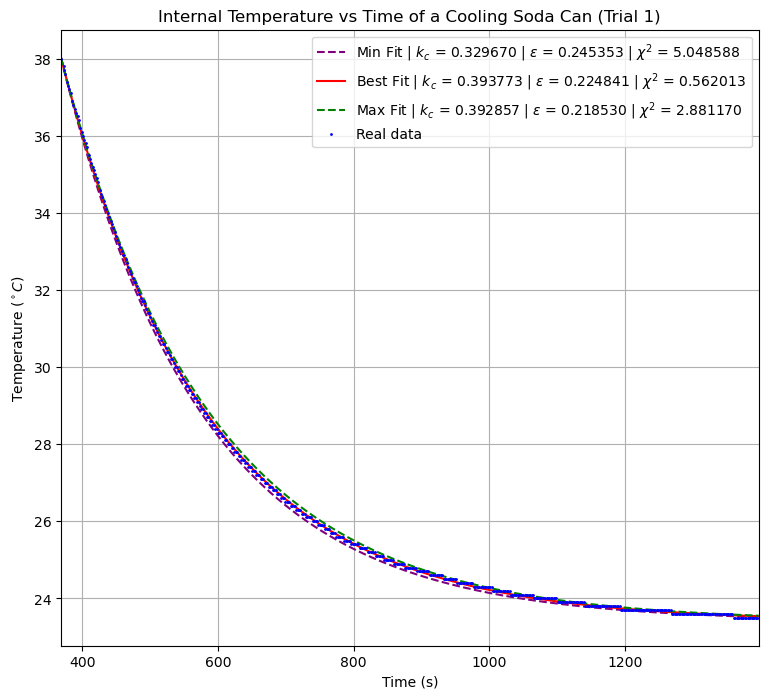

In [35]:
for dataset in datasets: 

    time_array, temperature_array, rh_array = readfile(goodPath + dataset.name + ".csv")

    temperature_array = temperature_array[time_array > dataset.trim]
    time_array = time_array[time_array > dataset.trim]

    plt.figure(figsize=(9, 8))

    # fig, ax = plt.subplots()
    # ax.set_xlabel('Time [s]')

    # color = 'tab:blue'
    # ax.plot(time_array, temperature_array, marker='o', linestyle='--', color=color, ms=2)
    # ax.set_ylabel("Temperature ($^\\circ C$)", color=color)
    # # ax.set_ylim([15,50])
    # ax.grid(visible=True, axis='x')
    # ax.tick_params(axis='y', labelcolor=color)
    # ax.set_xlabel('time (s)')

    # line, = ax.plot(t, T, lw=2, color='tab:red')
    # chi_text = ax.text(0.5, 0.5, f'chi-squared {chiSquared(t, T, time_array, temperature_array)}', size=15, transform=ax.transAxes, ha='left', va='top')

    
    # plt.plot(t_array[arrays[0] > 0], arrays[0][arrays[0] > 0], "--", label="Euler with drag underestimate")
    # plt.plot(t_array[arrays[2] > 0], arrays[2][arrays[2] > 0], "--", label="Euler with drag overestimate")
    

    descriptions = ["Min", "Best", "Max"]
    colors = ["purple", "red", "green"]
    dashes = ["--", "-", "--"]

    for kc, ep, description, colour, dash in zip(dataset.kcs, dataset.eps, descriptions, colors, dashes):

        t, T = euler(kc, ep, dataset.start_time, dataset.start_temp, time_array[-1], dataset.tamb)

        plt.plot(t, T, dash, label=f"{description} Fit | $k_c$ = {kc:4f} | $\\epsilon$ = {ep :4f} | $\\chi^2$ = {chiSquared(t, T, time_array, temperature_array) :4f}", color=colour)

    # plt.plot(t, T, "r-", label=f"Min Fit | $k_c$ = {dataset.kc_min:4f} | $\\epsilon$ = {dataset.eps_min :4f} | $\\chi^2$ = {dataset.chi :4f}")

    
    plt.plot(time_array, temperature_array, "b.", label="Real data", ms=2)


    plt.title(f"Internal Temperature vs Time of a Cooling Soda Can (Trial {dataset.name})")
    plt.xlabel("Time (s)")
    plt.ylabel("Temperature ($^\\circ C$)")
    plt.xlim(time_array[0], time_array[-1])
    plt.grid(True)
    plt.legend()
    plt.savefig(figures_folder + f"/EulerFit{dataset.name}.svg")
    plt.show()

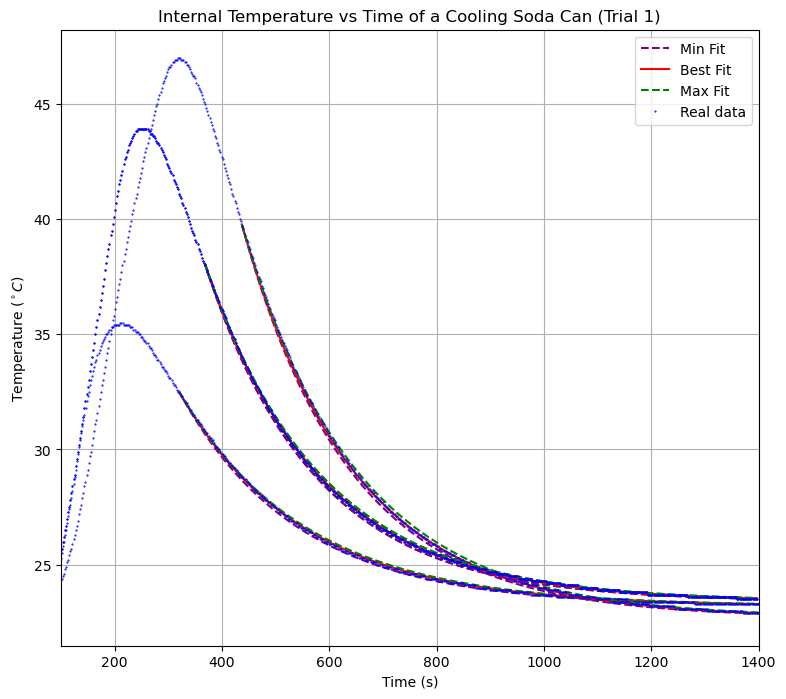

In [42]:
plt.figure(figsize=(9, 8))

for dataset in datasets: 

    time_array, temperature_array, rh_array = readfile(goodPath + dataset.name + ".csv")

    # temperature_array = temperature_array[time_array > dataset.trim]
    # time_array = time_array[time_array > dataset.trim]


    # fig, ax = plt.subplots()
    # ax.set_xlabel('Time [s]')

    # color = 'tab:blue'
    # ax.plot(time_array, temperature_array, marker='o', linestyle='--', color=color, ms=2)
    # ax.set_ylabel("Temperature ($^\\circ C$)", color=color)
    # # ax.set_ylim([15,50])
    # ax.grid(visible=True, axis='x')
    # ax.tick_params(axis='y', labelcolor=color)
    # ax.set_xlabel('time (s)')

    # line, = ax.plot(t, T, lw=2, color='tab:red')
    # chi_text = ax.text(0.5, 0.5, f'chi-squared {chiSquared(t, T, time_array, temperature_array)}', size=15, transform=ax.transAxes, ha='left', va='top')

    
    # plt.plot(t_array[arrays[0] > 0], arrays[0][arrays[0] > 0], "--", label="Euler with drag underestimate")
    # plt.plot(t_array[arrays[2] > 0], arrays[2][arrays[2] > 0], "--", label="Euler with drag overestimate")
    

    descriptions = ["Min", "Best", "Max"]
    colors = ["purple", "red", "green"]
    dashes = ["--", "-", "--"]

    for kc, ep, description, colour, dash in zip(dataset.kcs, dataset.eps, descriptions, colors, dashes):

        t, T = euler(kc, ep, dataset.start_time, dataset.start_temp, time_array[-1], dataset.tamb)

        plt.plot(t, T, dash, color=colour)


        if dataset.name == "1": 
            plt.plot(t, T, dash, label=f"{description} Fit", color=colour)



    # plt.plot(t, T, "r-", label=f"Min Fit | $k_c$ = {dataset.kc_min:4f} | $\\epsilon$ = {dataset.eps_min :4f} | $\\chi^2$ = {dataset.chi :4f}")

    if dataset.name == "1": 
        plt.plot(time_array, temperature_array, "b.", label="Real data", ms=1)

    plt.plot(time_array, temperature_array, "b.", ms=1)


plt.title(f"Internal Temperature vs Time of a Cooling Soda Can (Trial {dataset.name})")
plt.xlabel("Time (s)")
plt.ylabel("Temperature ($^\\circ C$)")
plt.xlim(100, 1400)
plt.grid(True)
plt.legend()
plt.savefig(figures_folder + f"/EulerFitAll.svg")
plt.show()

In [ ]:
for dataset in datasets: 

    time_array, temperature_array, rh_array = readfile(goodPath + dataset.name + ".csv")

    temperature_array = temperature_array[time_array > dataset.trim]
    time_array = time_array[time_array > dataset.trim]

    descriptions = ["Min", "Best", "Max"]
    colors = ["purple", "red", "green"]
    dashes = ["--", "-", "--"]

    # for kc, ep, description, colour, dash in zip(dataset.kcs, dataset.eps, descriptions, colors, dashes):

    t, T = euler(dataset.kcs[1], dataset.eps[1], dataset.start_time, dataset.start_temp, time_array[-1], dataset.tamb)

    print(f"name: {dataset.name}")
    print(f"k_c: {dataset.kcs[1]:4f}")
    print(f"del_k_c: {(dataset.kcs[1] - dataset.kcs[0])/4:4f}")
    
    print(f"chi2: {chiSquared(t, T, time_array, temperature_array):4f}")



name: 3
k_c: 0.413004
del_k_c: 0.036859
chi2: 0.729672
name: 4
k_c: 0.301282
del_k_c: -0.073260
chi2: 1.661023
name: 1
k_c: 0.393773
del_k_c: 0.016026
chi2: 0.562013
